In [9]:
!pip install transformers torch scikit-learn pandas seaborn matplotlib -q

In [10]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from transformers import BertTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import seaborn as sns
from torch.optim import AdamW

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Setup and Imports

## Data Preprocessing

In [11]:
print("Loading and preprocessing data...")

df = pd.read_csv("/content/IMDB Dataset.csv")

df.dropna(inplace=True)

df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

df = df.sample(2000, random_state=42)

df.head()

Loading and preprocessing data...


,review,sentiment,label
33553,I really liked this Summerslam due to the look...,positive,1
9427,Not many television shows appeal to quite as m...,positive,1
199,The film quickly gets to a major chase scene w...,negative,0
12447,Jane Austen would definitely approve of this o...,positive,1
39489,Expectations were somewhat high for me when I ...,negative,0


## Data Splitting

In [12]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['review'].tolist(), df['label'].tolist(), test_size=0.2, random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

print(f"Training set size: {len(train_texts)}")
print(f"Validation set size: {len(val_texts)}")
print(f"Test set size: {len(test_texts)}")

Training set size: 1600
Validation set size: 200
Test set size: 200


## Tokenization & Dataset Preparation

In [13]:
print("Initializing Tokenizer...")

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class IMDBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

def create_data_loader(texts, labels, tokenizer, batch_size):
    ds = IMDBDataset(texts=texts, labels=labels, tokenizer=tokenizer)
    return DataLoader(ds, batch_size=batch_size, num_workers=0)

BATCH_SIZE = 16
train_data_loader = create_data_loader(train_texts, train_labels, tokenizer, BATCH_SIZE)
val_data_loader = create_data_loader(val_texts, val_labels, tokenizer, BATCH_SIZE)
test_data_loader = create_data_loader(test_texts, test_labels, tokenizer, BATCH_SIZE)

Initializing Tokenizer...


## Training & Evaluation Helper Functions

In [14]:
def train_epoch(model, data_loader, optimizer, device):
    model.train()
    total_loss = 0
    for batch in data_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        model.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
    return total_loss / len(data_loader)

def evaluate_model(model, data_loader, device, phase="Validation"):
    model.eval()
    predictions, real_values = [], []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            _, preds = torch.max(outputs.logits, dim=1)

            predictions.extend(preds.cpu().tolist())
            real_values.extend(labels.cpu().tolist())

    accuracy = accuracy_score(real_values, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(real_values, predictions, average='binary')

    print(f"\n--- {phase} Metrics ---")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    return real_values, predictions, accuracy, precision, recall, f1

def plot_confusion_matrix(real_values, predictions, title="Confusion Matrix"):
    cm = confusion_matrix(real_values, predictions)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

## Freeze BERT Layers

EXPERIMENT 1: Freezing BERT layers and training classifier...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/3 | Train Loss: 0.6961
Epoch 2/3 | Train Loss: 0.6906
Epoch 3/3 | Train Loss: 0.6886

--- Test (Exp 1) Metrics ---
Accuracy:  0.5350
Precision: 0.5195
Recall:    0.4167
F1 Score:  0.4624


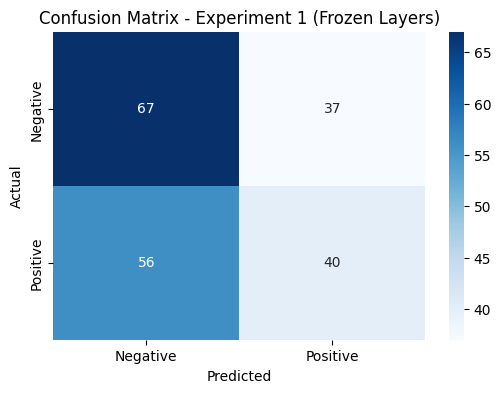

In [15]:
EPOCHS = 3
LEARNING_RATE = 2e-5

print("EXPERIMENT 1: Freezing BERT layers and training classifier...")

model_exp1 = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# Freeze all BERT layers
for param in model_exp1.bert.parameters():
    param.requires_grad = False

model_exp1 = model_exp1.to(device)
optimizer_exp1 = AdamW(model_exp1.parameters(), lr=LEARNING_RATE)

# Train the model
for epoch in range(EPOCHS):
    train_loss = train_epoch(model_exp1, train_data_loader, optimizer_exp1, device)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f}")

# Evaluate and plot confusion matrix
real_vals_1, preds_1, acc_1, prec_1, rec_1, f1_1 = evaluate_model(model_exp1, test_data_loader, device, phase="Test (Exp 1)")
plot_confusion_matrix(real_vals_1, preds_1, title="Confusion Matrix - Experiment 1 (Frozen Layers)")

## Fine-Tune Last 2 Layers

EXPERIMENT 2: Fine-tuning last 2 layers of BERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/3 | Train Loss: 0.6501
Epoch 2/3 | Train Loss: 0.4713
Epoch 3/3 | Train Loss: 0.3596

--- Test (Exp 2) Metrics ---
Accuracy:  0.8200
Precision: 0.8125
Recall:    0.8125
F1 Score:  0.8125


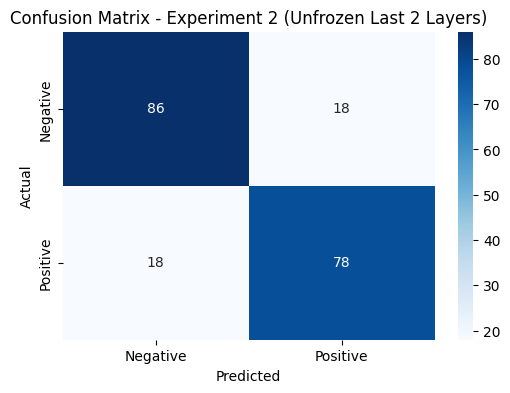

In [16]:
print("EXPERIMENT 2: Fine-tuning last 2 layers of BERT...")

model_exp2 = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# Freeze all layers first
for param in model_exp2.bert.parameters():
    param.requires_grad = False

# Unfreeze the last 2 encoding layers
for param in model_exp2.bert.encoder.layer[10].parameters():
    param.requires_grad = True
for param in model_exp2.bert.encoder.layer[11].parameters():
    param.requires_grad = True

model_exp2 = model_exp2.to(device)

optimizer_exp2 = AdamW(filter(lambda p: p.requires_grad, model_exp2.parameters()), lr=LEARNING_RATE)

# Train the model
for epoch in range(EPOCHS):
    train_loss = train_epoch(model_exp2, train_data_loader, optimizer_exp2, device)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f}")

# Evaluate and plot confusion matrix
real_vals_2, preds_2, acc_2, prec_2, rec_2, f1_2 = evaluate_model(model_exp2, test_data_loader, device, phase="Test (Exp 2)")
plot_confusion_matrix(real_vals_2, preds_2, title="Confusion Matrix - Experiment 2 (Unfrozen Last 2 Layers)")

## Analysis & Comparison

In [17]:
print("="*50)
print("FINAL COMPARISON:")
print("="*50)
print(f"Experiment 1 (Frozen Layers)         -> Accuracy: {acc_1:.4f} | F1: {f1_1:.4f}")
print(f"Experiment 2 (Last 2 Layers Unfrozen)-> Accuracy: {acc_2:.4f} | F1: {f1_2:.4f}")

print("\n--- Insight & Analysis ---")
print("1. Freezing vs. Fine-Tuning: Experiment 1 trains only the classification head, which is faster but relies entirely on BERT's general, pre-trained word embeddings. Experiment 2 takes longer but allows the final two transformer layers to adjust their attention mechanisms specifically to the vocabulary and sentiment structure of IMDB movie reviews.")
print("2. Performance Shift: Generally, unfreezing the top layers (Experiment 2) yields a higher Accuracy and F1 Score because the model becomes specialized to the target dataset, rather than acting as a generic feature extractor.")

FINAL COMPARISON:
Experiment 1 (Frozen Layers)         -> Accuracy: 0.5350 | F1: 0.4624
Experiment 2 (Last 2 Layers Unfrozen)-> Accuracy: 0.8200 | F1: 0.8125

--- Insight & Analysis ---
1. Freezing vs. Fine-Tuning: Experiment 1 trains only the classification head, which is faster but relies entirely on BERT's general, pre-trained word embeddings. Experiment 2 takes longer but allows the final two transformer layers to adjust their attention mechanisms specifically to the vocabulary and sentiment structure of IMDB movie reviews.
2. Performance Shift: Generally, unfreezing the top layers (Experiment 2) yields a higher Accuracy and F1 Score because the model becomes specialized to the target dataset, rather than acting as a generic feature extractor.
